In [7]:
def plot_image_with_boxes(image, boxes, labels=None, color='red', linewidth=2):
    """
    Plots an image and draws bounding boxes on it.

    Args:
        image (np.ndarray): The image as a NumPy array.
        boxes (list or np.ndarray): A list of bounding boxes, where each box is
                                    in the format [x_min, y_min, x_max, y_max].
        labels (list, optional): A list of labels for each bounding box.
        color (str): The color of the bounding box outlines.
        linewidth (int): The thickness of the bounding box lines.
    """
    # Create figure and axes
    fig, ax = plt.subplots(1)

    # Display the image
    ax.imshow(image)
    height, width = image.shape[:2]

    # Check if a single box was passed and wrap it in a list
    if not isinstance(boxes[0], (list, np.ndarray)):
        boxes = [boxes]

    # Iterate over each bounding box
    for i, box in enumerate(boxes):
        x_min, y_min, x2, y2 = box
        # x_min = x_c - w/2
        # y_min = y_c - h/2  
        w = x2 - x_min
        h = y2 - y_min
        x_min = x_min * width
        w = w* width
        y_min = y_min * height
        h = h* height      
        # Calculate the width and height of the box
        # width = x_max - x_min
        # height = y_max - y_min
        
        # Create a Rectangle patch
        rect = patches.Rectangle(
            (x_min, y_min), w, h,
            linewidth=linewidth, edgecolor=color, facecolor='none'
        )

        # Add the patch to the Axes
        ax.add_patch(rect)

        # Add a label if provided
        if labels and len(labels) > i:
            ax.text(
                x_min, y_min - 5, labels[i],
                color=color, fontsize=12,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
            )

    # Turn off the axis to show only the image
    ax.axis('off')
    
    # Display the plot
    plt.show()

In [ ]:
import cv2
import numpy as np
import os
from typing import Optional, Tuple

class VideoFrameExtractor:
    def __init__(self, video_path: str):
        """
        Initialize the video frame extractor.
        
        Args:
            video_path (str): Path to the video file
        """
        self.video_path = video_path
        self.cap = None
        self.fps = 0
        self.total_frames = 0
        self.duration = 0
        
        if not os.path.exists(video_path):
            raise FileNotFoundError(f"Video file not found: {video_path}")
        
        self._initialize_video()
    
    def _initialize_video(self):
        """Initialize video capture and get video properties."""
        self.cap = cv2.VideoCapture(self.video_path)
        
        if not self.cap.isOpened():
            raise ValueError(f"Could not open video file: {self.video_path}")
        
        # Get video properties
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.duration = self.total_frames / self.fps if self.fps > 0 else 0
        
        print(f"Video Info:")
        print(f"- FPS: {self.fps}")
        print(f"- Total Frames: {self.total_frames}")
        print(f"- Duration: {self.duration:.2f} seconds")
    
    def get_frame_at_time(self, second: float, frame_in_second: int = 0) -> Optional[np.ndarray]:
        """
        Extract a frame at a specific second and frame within that second.
        
        Args:
            second (float): The target second in the video
            frame_in_second (int): Frame number within that second (0-based)
        
        Returns:
            np.ndarray: The extracted frame as a numpy array, or None if failed
        """
        if second < 0 or second > self.duration:
            print(f"Error: Second {second} is out of range (0 - {self.duration:.2f})")
            return None
        
        if frame_in_second < 0 or frame_in_second >= int(self.fps):
            print(f"Error: Frame {frame_in_second} is out of range (0 - {int(self.fps)-1})")
            return None
        
        # Calculate the exact frame number
        target_frame = int(second * self.fps) + frame_in_second
        
        if target_frame >= self.total_frames:
            print(f"Error: Calculated frame {target_frame} exceeds total frames {self.total_frames}")
            return None
        
        # Set video position to target frame
        self.cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        
        # Read the frame
        ret, frame = self.cap.read()
        
        if not ret:
            print(f"Error: Could not read frame {target_frame}")
            return None
        
        print(f"Successfully extracted frame {target_frame} (second {second}, frame {frame_in_second})")
        return frame
    
    def save_frame(self, frame: np.ndarray, output_path: str) -> bool:
        """
        Save a frame to disk.
        
        Args:
            frame (np.ndarray): The frame to save
            output_path (str): Path where to save the frame
        
        Returns:
            bool: True if successful, False otherwise
        """
        try:
            success = cv2.imwrite(output_path, frame)
            if success:
                print(f"Frame saved to: {output_path}")
                return True
            else:
                print(f"Failed to save frame to: {output_path}")
                return False
        except Exception as e:
            print(f"Error saving frame: {e}")
            return False
    
    def get_video_info(self) -> dict:
        """
        Get detailed video information.
        
        Returns:
            dict: Dictionary containing video properties
        """
        return {
            'fps': self.fps,
            'total_frames': self.total_frames,
            'duration': self.duration,
            'width': int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
            'height': int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
            'codec': int(self.cap.get(cv2.CAP_PROP_FOURCC))
        }
    
    def close(self):
        """Release video capture resources."""
        if self.cap:
            self.cap.release()
    
    def __enter__(self):
        """Context manager entry."""
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        """Context manager exit."""
        self.close()


# Example usage and demonstration
def main():
    """Demonstrate how to use the VideoFrameExtractor."""
    
    # Example usage - replace with your video file path
    video_path = "sample_video.mp4"  # Change this to your video file path
    
    try:
        # Using context manager for automatic cleanup
        with VideoFrameExtractor(video_path) as extractor:
            # Get video info
            info = extractor.get_video_info()
            print(f"\nDetailed Video Info: {info}")
            
            # Extract frame at 5.5 seconds, frame 10 within that second
            second = 5.5
            frame_num = 10
            
            frame = extractor.get_frame_at_time(second, frame_num)
            
            if frame is not None:
                # Save the extracted frame
                output_path = f"extracted_frame_{second}s_frame{frame_num}.jpg"
                extractor.save_frame(frame, output_path)
                
                # Display frame info
                height, width = frame.shape[:2]
                print(f"Frame dimensions: {width}x{height}")
                
                # Optional: Display the frame (uncomment if you have a display)
                # cv2.imshow('Extracted Frame', frame)
                # cv2.waitKey(0)
                # cv2.destroyAllWindows()
            
            # Extract multiple frames
            print("\n--- Extracting multiple frames ---")
            frames_to_extract = [
                (1.0, 0),   # 1 second, frame 0
                (1.0, 5),   # 1 second, frame 5
                (2.5, 0),   # 2.5 seconds, frame 0
            ]
            
            for sec, frame_idx in frames_to_extract:
                frame = extractor.get_frame_at_time(sec, frame_idx)
                if frame is not None:
                    output_name = f"frame_{sec}s_{frame_idx}.jpg"
                    extractor.save_frame(frame, output_name)
    
    except FileNotFoundError:
        print("Please update the 'video_path' variable with a valid video file path.")
    except Exception as e:
        print(f"An error occurred: {e}")


# if __name__ == "__main__":
#     main()

Please update the 'video_path' variable with a valid video file path.


In [2]:
frame_extractor = VideoFrameExtractor("ava_data/_145Aa_xkuE.mp4")

Video Info:
- FPS: 25.0
- Total Frames: 22356
- Duration: 894.24 seconds


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [8]:
import pandas as pd

In [3]:
frame = frame_extractor.get_frame_at_time(5, 0)

Successfully extracted frame 125 (second 5, frame 0)


In [9]:
train = pd.read_csv("ava_train_v2.2.csv")

In [ ]:
train = train[(train['id'] =="_145Aa_xkuE" ]

In [13]:
display(train[train["time"] == 902 + 5])
filtered = train[train["time"] == 902 + 5]

,id,time,x1,y1,x2,y2,action,tag
493110,_145Aa_xkuE,907,0.112,0.098,0.669,0.989,12,0
493111,_145Aa_xkuE,907,0.112,0.098,0.669,0.989,79,0
493112,_145Aa_xkuE,907,0.584,0.250,0.883,0.999,12,1
493113,_145Aa_xkuE,907,0.584,0.250,0.883,0.999,74,1
493114,_145Aa_xkuE,907,0.584,0.250,0.883,0.999,80,1


In [14]:
boxes = np.array(filtered[['x1', 'y1', 'x2', 'y2']])

In [15]:
boxes

array([[0.112, 0.098, 0.669, 0.989],
       [0.112, 0.098, 0.669, 0.989],
       [0.584, 0.25 , 0.883, 0.999],
       [0.584, 0.25 , 0.883, 0.999],
       [0.584, 0.25 , 0.883, 0.999]])

In [ ]:
frame = frame_extractor.get_frame_at_time(5, 0)

In [18]:
FPS = 25

Successfully extracted frame 16000 (second 640, frame 0)


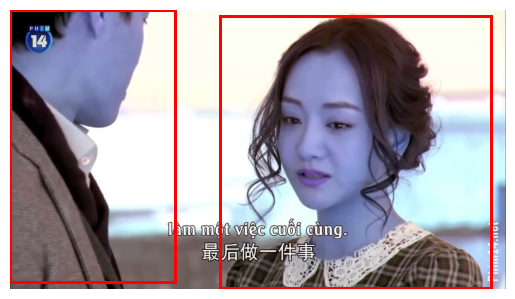

Successfully extracted frame 16005 (second 640, frame 5)


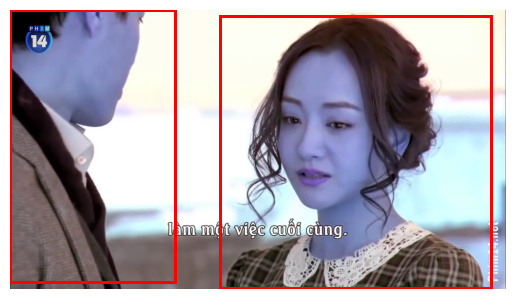

Successfully extracted frame 16010 (second 640, frame 10)


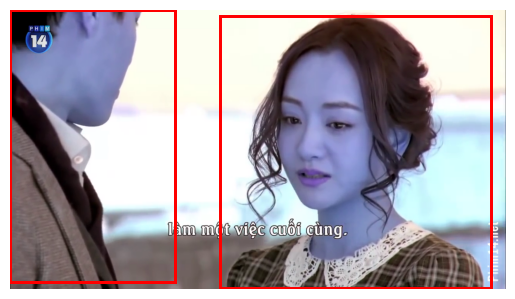

Successfully extracted frame 16015 (second 640, frame 15)


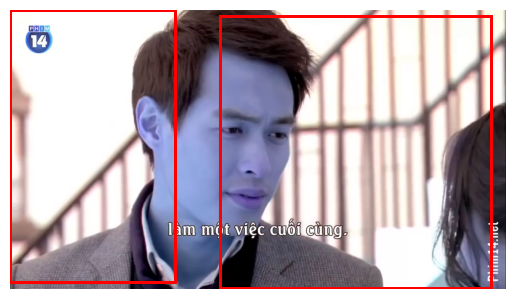

Successfully extracted frame 16020 (second 640, frame 20)


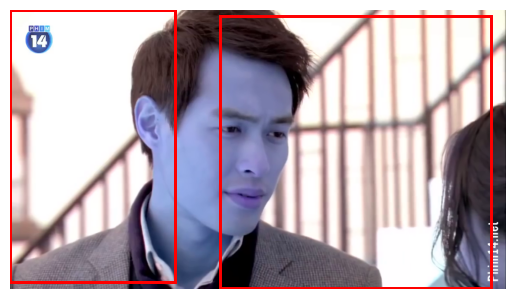

In [23]:
second = 640
for i in range(0,FPS, 5):
    frame = frame_extractor.get_frame_at_time(second, i)
    filtered = train[train["time"] == 902 + second]
    boxes = np.array(filtered[['x1', 'y1', 'x2', 'y2']])
    plot_image_with_boxes(frame, boxes)